<table>
  <tr>
    <td><div align="left"><font size="30">Gamma encoding</font></div></td>
    <td><img src="https://github.com/petercorke/machinevision-toolbox-python/raw/main/figs/VisionToolboxLogo_NoBackgnd@2x.png?raw=1" width="200"></td>
  </tr>
</table>

(c) Peter Corke 2024

Robotics, Vision & Control: Python, see Chapter 11

## Configuring the Jupyter environment
We need to import some packages to help us with linear algebra (`numpy`), graphics (`matplotlib`), and machine vision (`machinevisiontoolbox`).
If you're running locally you need to have these packages installed.  If you're running on CoLab we have to first install machinevisiontoolbox which is not preinstalled, this will be a bit slow.

In [5]:
try:
    import google.colab
    print('Running on CoLab')
    !pip install machinevision-toolbox-python
    COLAB = True
except:
    COLAB = False

%matplotlib widget
import matplotlib.pyplot as plt

import numpy as np
from machinevisiontoolbox import *

# display result of assignments
if COLAB:
    %config ZMQInteractiveShell.ast_node_interactivity = 'last_expr_or_assign'
# make NumPy display a bit nicer
np.set_printoptions(linewidth=100, formatter={'float': lambda x: f"{x:10.4g}" if abs(x) > 1e-10 else f"{0:10.4g}"})

# Gamma

Gamma encoding and decoding is discussed in Section 10.3.6 of **Robotics, Vision & Control: Python**.  We will create an image of what a photographer calls a step wedge

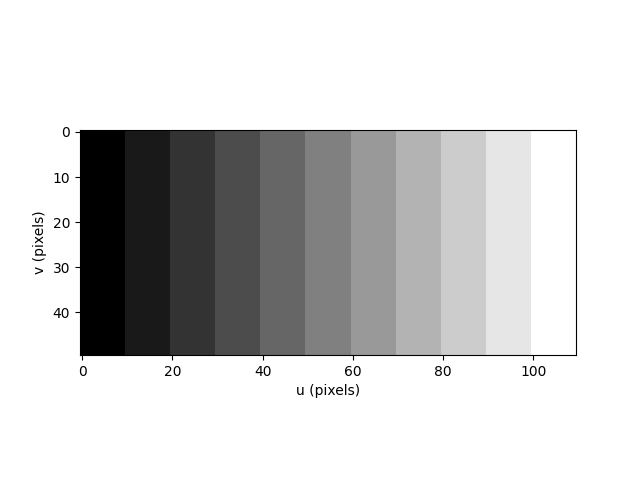

In [7]:
a = np.tile(np.repeat(np.arange(0, 1.1, 0.1), 10), (50, 1))
idisp(a);

Explore the pixel values with the cursor. The third bar has twice the pixel value of the second bar but it doesn't appear this way.  The last bar has twice the pixel value of the second last bar -- again the intensitites on the screen don't reflect that.

We need to remember that the pixel values go to a monitor which (by inherent physics or design) displays an intensity that is the pixel value to the power of ~2.2 -- we are seeing the pixel values squared!

Let's now display the square root of our image

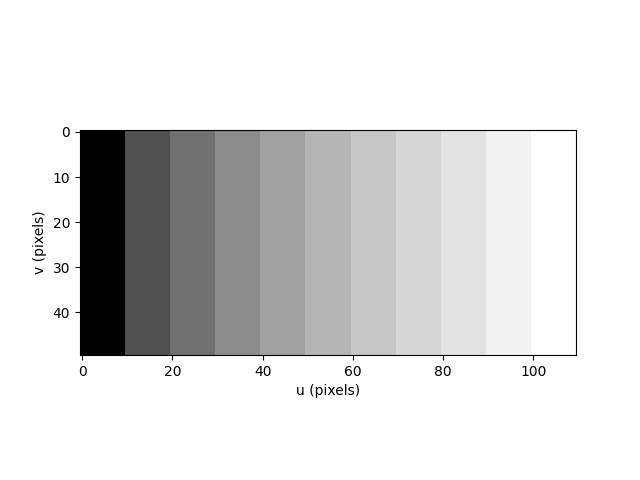

In [8]:
idisp(np.sqrt(a))


We see that the brightness steps now seem much more linear. This is only an approximation of the required gamma decoding but it shows the monitor non-linearity very clearly.

**The really important message is that the pixel values in an image files are the square-root of the intensities in the scene**.